In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def printSampledFromBook(book: str, distribution: str, tau: float | None = None):
    results_dir = Path("results")
    summary_paths = sorted(results_dir.rglob("summary.json"))

    if not summary_paths:
        print("No summary.json files found under results/")
        return

    plt.figure(figsize=(12, 6))

    plotted_any = False
    tau_label_added = False  # <-- ensures only one legend entry

    for summary_path in summary_paths:
        rel_parts = summary_path.relative_to(results_dir).parts
        folder_parts = rel_parts[:-1]

        if not folder_parts:
            continue

        if len(folder_parts) == 1:
            title = folder_parts[0]
        else:
            title = ", ".join(folder_parts[:0:-1]) + f" ({folder_parts[0]})"

        if book not in title:
            continue

        if "= 0" in title:
            continue
        if not "Monte Carlo" in title or not distribution in title:
            continue

        windows_csv = summary_path.parent / "windows.csv"
        if not windows_csv.exists():
            print(f"Missing windows.csv for: {title}")
            continue

        try:
            df = pd.read_csv(windows_csv)
        except Exception as e:
            print(f"Could not read {windows_csv}: {e}")
            continue

        required_cols = {"window_index", "p_z"}
        if not required_cols.issubset(df.columns):
            print(f"Skipping {title}: missing columns {required_cols - set(df.columns)}")
            continue

        df = df.copy()
        df["window_index"] = pd.to_numeric(df["window_index"], errors="coerce")
        df["p_z"] = pd.to_numeric(df["p_z"], errors="coerce")
        df = df.dropna(subset=["window_index", "p_z"])

        if df.empty:
            print(f"Skipping {title}: no valid data")
            continue

        df = df.sort_values("window_index")

        title_parts = title.split(", ")
        if len(title_parts) > 1:
            title = ", ".join(title_parts[1:])
        # --- main line plot ---
        plt.plot(
            df["window_index"],
            df["p_z"],
            marker="o",
            markersize=3,
            label=title
        )

        # --- highlight points below tau (only if tau is provided) ---
        if tau is not None:
            below_tau = df[df["p_z"] < tau]
            if not below_tau.empty:
                plt.scatter(
                    below_tau["window_index"],
                    below_tau["p_z"],
                    facecolors="none",
                    edgecolors="red",
                    s=60,
                    linewidths=1.5,
                    label=(
                        f"points below threshold τ = {tau}"
                        if not tau_label_added else None
                    )
                )
                tau_label_added = True

        plotted_any = True

    if not plotted_any:
        print(f"No matching data found for book: {book}")
        plt.close()
        return

    plt.xlabel("window_index")
    plt.ylabel("p_z")
    plt.title(f"LLaDA to Llama comparison on {book} with {distribution} distribution")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(fontsize=8)
    plt.tight_layout()

    
    # --- save figure ---
    output_path = Path("plots")
    output_path.mkdir(exist_ok=True)
    
    filename = f"{book}_{distribution}.png".replace(" ", "_")
    plt.savefig(output_path / filename, dpi=300, bbox_inches="tight")
    
    plt.show()

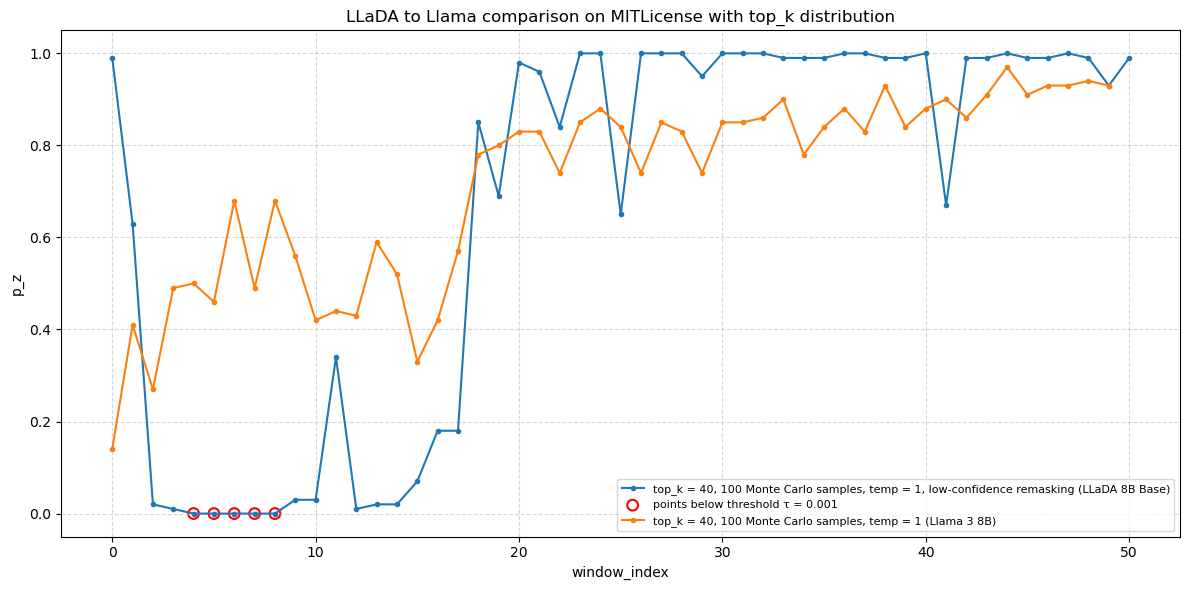

In [8]:
printSampledFromBook("MITLicense","top_k",0.001)

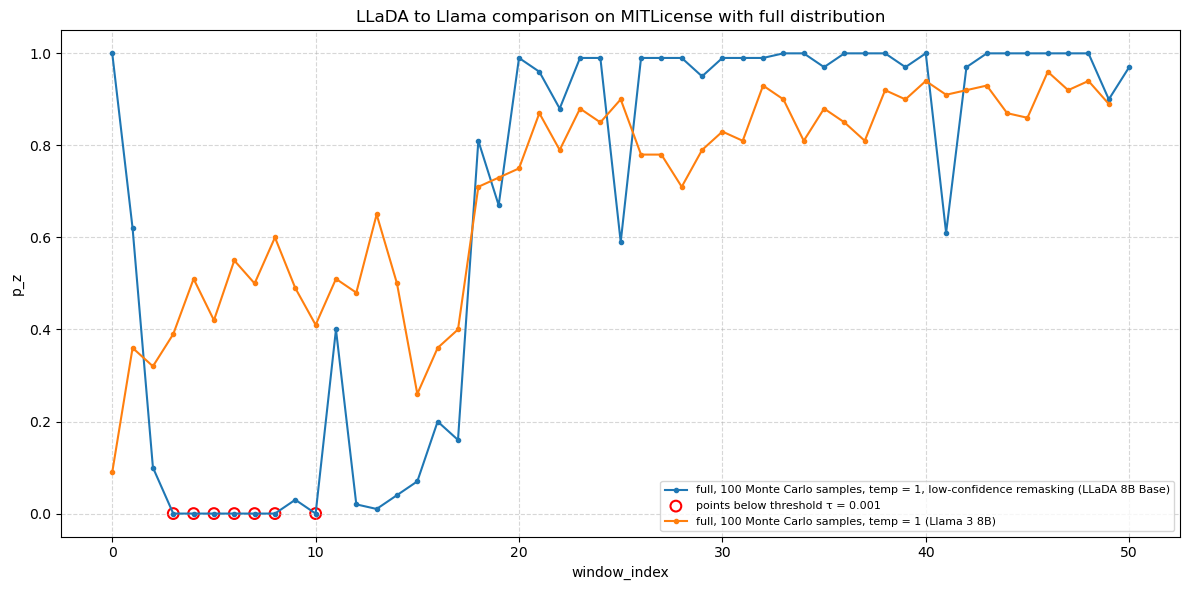

In [9]:
printSampledFromBook("MITLicense","full",0.001)

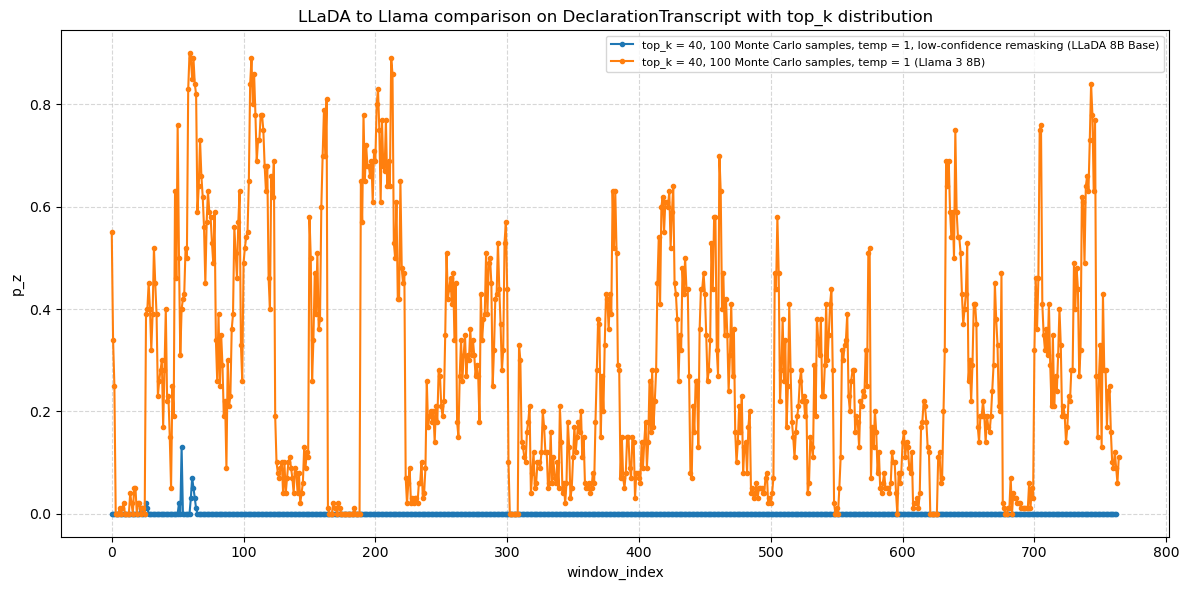

In [10]:
printSampledFromBook("DeclarationTranscript","top_k")

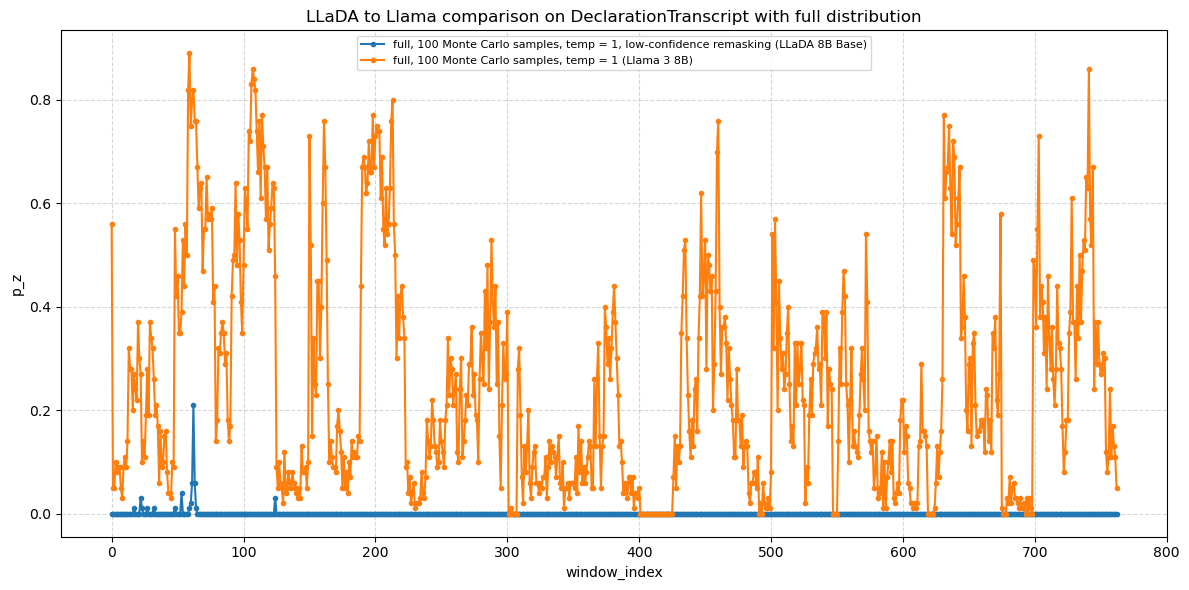

In [11]:
printSampledFromBook("DeclarationTranscript","full")